# P5EN AllReduce (NCCL_TESTS_SPLIT_MASK=0x7) - Latency & Bandwidth Realistic Model

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # repo root: realistic_model/ packages
from roofline_model import parse_section_data, extract_configs
from realistic_model import PlatformConfig, RealisticParams, compute_ring_simple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

cfg = PlatformConfig.load('p5en')   # platform hardware params (a, NIC BW)

# Parse ALL nccl_test results from multiple node-scale files
DATA_DIR = '.'
node_files = {
    4: f'{DATA_DIR}/nccl_test_4nodes_0x7_p5en.out',
    8: f'{DATA_DIR}/nccl_test_8nodes_0x7_p5en.out',
    16: f'{DATA_DIR}/nccl_test_16nodes_0x7_p5en.out',
}

# Parse each file into sections
all_sections_by_nodes = {}
for n_nodes_scale, fpath in node_files.items():
    if not os.path.exists(fpath):
        print(f"  SKIP {n_nodes_scale} nodes: file not found")
        continue
    with open(fpath, 'r') as f:
        content = f.read()
    all_sections_by_nodes[n_nodes_scale] = re.split(r'={10,}\nConfig:', content)
    print(f"  Loaded {n_nodes_scale} nodes: {len(all_sections_by_nodes[n_nodes_scale])} sections")

# Parse Ring/Simple per node scale.  Structure: all_data[n_nodes][('Ring','Simple')] = {nch: DataFrame}
all_data = {}
for n_nodes_scale, sections in all_sections_by_nodes.items():
    all_data[n_nodes_scale] = {
        ('Ring', 'Simple'): extract_configs('Ring', 'Simple', sections),
    }


# Message size range for Simple
PROTO_SIZE_RANGES = {
    'Simple': (512 * 1024, float('inf')),  # 512KB and above
}

  Loaded 4 nodes: 31 sections
  Loaded 8 nodes: 31 sections
  Loaded 16 nodes: 31 sections


In [2]:
# P2P latency parameter a (fixed startup latency == alpha), from config.json.
# a = mean of pping inter-node RTT for small messages (<= 32 B); only 'a' is used.
a = cfg.a_us

In [ ]:
# ============================================================
# Profiling-calibrated overhead parameters: O_net, O_mem, O_round
# ------------------------------------------------------------
# REGENERATED here from the raw NCCL profiling dump, then loaded. The whole parse->fit->
# assemble->write pipeline lives in realistic_model.extraction.build_overhead(); editing the
# generation logic there and re-running this notebook is enough to refresh overhead.json AND
# the plots below (fully decoupled from the overhead-analysis notebook).
#   O_net(us), O_mem(us), O_round(us):  linear fit k*slice_KB + b per nch 
# ============================================================
from realistic_model import RealisticParams, extraction as ex
_OUT_PATH  = 'nccl_allreduce_ring_inter_r-0-0x7.out'
_JSON_PATH = '../realistic_model/overhead.json'
ex.build_overhead(_OUT_PATH, _JSON_PATH)          # regenerate the committed overhead.json
params = RealisticParams.from_json(_JSON_PATH)     # load it back for the model calls below

In [4]:
# AllReduce Realistic Model (Ring, Simple, 0x7)
# Overheads come from profiling-calibrated params.O_net_eff_us / O_mem_us / O_round_us
# (functions of chunk/slice + nch), loaded in the parameter cell above.
G_bytes_per_us = cfg.nic_bw_dual   # NIC bandwidth (bytes/us)

# Compute realistic AllReduce for every Ring/Simple channel count and node scale (4/8/16).
# Each node scale has its own busBW reporting factor 2(n-1)/n.
for _n_nodes_scale in sorted(all_data.keys()):
    _data = all_data[_n_nodes_scale].get(('Ring', 'Simple'), {})
    if not _data:
        continue
    _busbw_factor = 2 * (_n_nodes_scale - 1) / _n_nodes_scale
    for _nch in sorted(_data.keys()):
        _dft = _data[_nch]
        _sizes = _dft['size_bytes'].values
        _T = compute_ring_simple(params, _sizes, _n_nodes_scale, _nch, G_bytes_per_us, a / 2)
        _algbw = _sizes / (_T * 1e-6) / 1e9
        _dft['T_realistic_us'] = _T
        _dft['algbw_realistic_GBs'] = _algbw
        _dft['busbw_realistic_GBs'] = _algbw * _busbw_factor
    print(f"  Computed Ring/Simple realistic for {_n_nodes_scale} nodes ({len(_data)} channels)")

  Computed Ring/Simple realistic for 4 nodes (5 channels)
  Computed Ring/Simple realistic for 8 nodes (5 channels)
  Computed Ring/Simple realistic for 16 nodes (5 channels)


In [5]:
# Comparison table: Measured AllReduce (Ring, Simple) vs Realistic Model — all channels, all node scales
for _n_nodes_scale in sorted(all_data.keys()):
    _data = all_data[_n_nodes_scale].get(('Ring', 'Simple'), {})
    for nch in sorted(_data.keys()):
        dft = _data[nch]
        if 'T_realistic_us' not in dft.columns:
            continue
        print(f"\n{'=' * 100}")
        print(f"Ring/Simple/{nch}ch ({_n_nodes_scale} nodes): Measured vs Realistic")
        print(f"{'=' * 100}")
        print(f"{'Size':>12} {'T_meas':>10} {'T_roof':>10} {'ratio':>8} {'busBW_m':>8} {'busBW_r':>8} {'r/m':>6}")
        for _, row in dft.iterrows():
            t_ratio = row['time_us'] / row['T_realistic_us']
            bw_ratio = row['busbw_realistic_GBs'] / row['busbw_GBs'] if row['busbw_GBs'] > 0 else 0
            print(f"{row['size_bytes']:>12.0f} {row['time_us']:>10.1f} {row['T_realistic_us']:>10.1f} "
                  f"{t_ratio:>8.3f} {row['busbw_GBs']:>8.2f} {row['busbw_realistic_GBs']:>8.2f} {bw_ratio:>6.2f}")
        peak_meas = dft['busbw_GBs'].max()
        peak_roof = dft['busbw_realistic_GBs'].max()
        eff = dft['busbw_GBs'].iloc[-1] / dft['busbw_realistic_GBs'].iloc[-1] * 100
        print(f"  Peak meas={peak_meas:.2f}, roof={peak_roof:.2f} GB/s | Eff@largest: {eff:.1f}%")


Ring/Simple/1ch (4 nodes): Measured vs Realistic
        Size     T_meas     T_roof    ratio  busBW_m  busBW_r    r/m
        1024      141.2      197.5    0.715     0.01     0.01   0.78
        2048      140.5      197.6    0.711     0.02     0.02   0.78
        4096      141.1      197.7    0.714     0.04     0.03   0.78
        8192      142.5      197.9    0.720     0.09     0.06   0.69
       16384      148.1      198.3    0.747     0.17     0.12   0.73
       32768      162.4      199.1    0.816     0.30     0.25   0.82
       65536      186.3      200.8    0.928     0.53     0.49   0.92
      131072      204.2      204.1    1.001     0.96     0.96   1.00
      262144      223.2      210.6    1.060     1.76     1.87   1.06
      524288      231.3      223.8    1.034     3.40     3.51   1.03
     1048576      274.4      250.0    1.097     5.73     6.29   1.10
     2097152      316.7      302.5    1.047     9.93    10.40   1.05
     4194304      431.8      407.6    1.059    14.57 

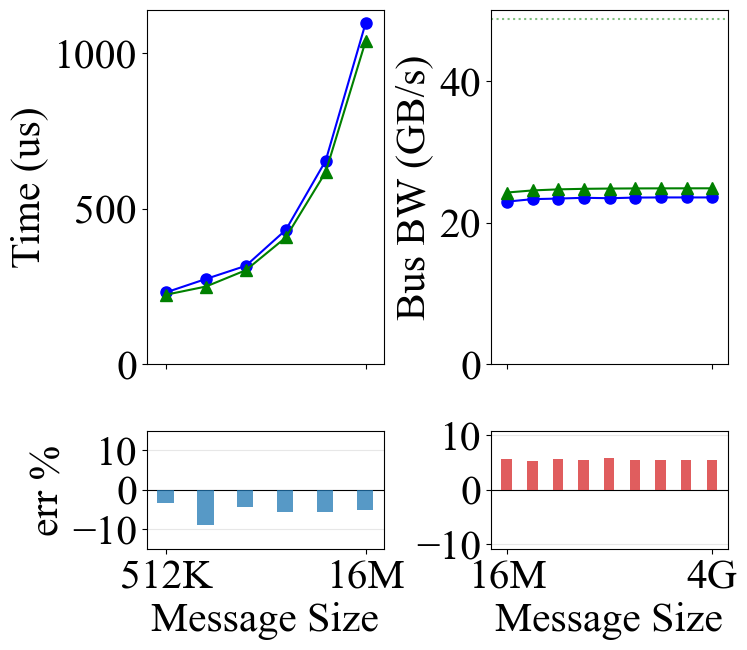

  Ring Simple 1ch (4N): peak meas=23.55, roof=24.84, ratio=0.948


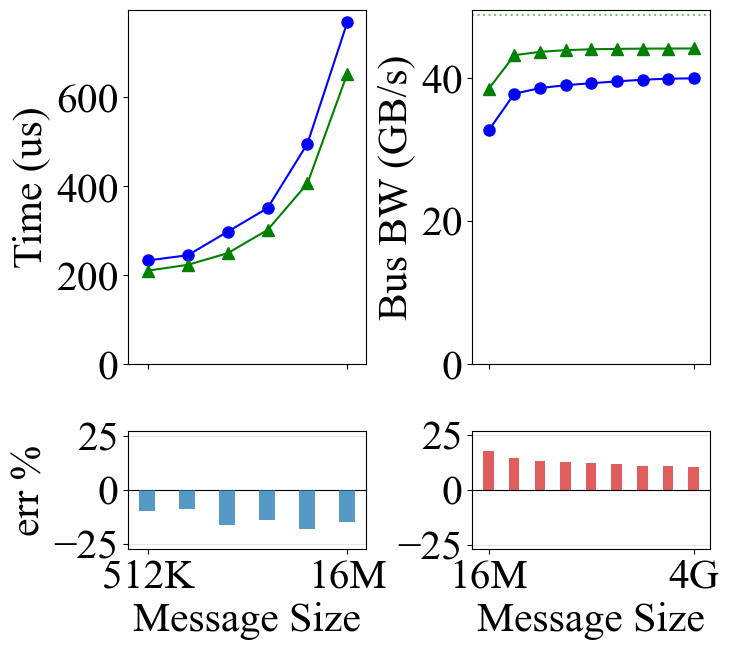

  Ring Simple 2ch (4N): peak meas=39.96, roof=44.14, ratio=0.905


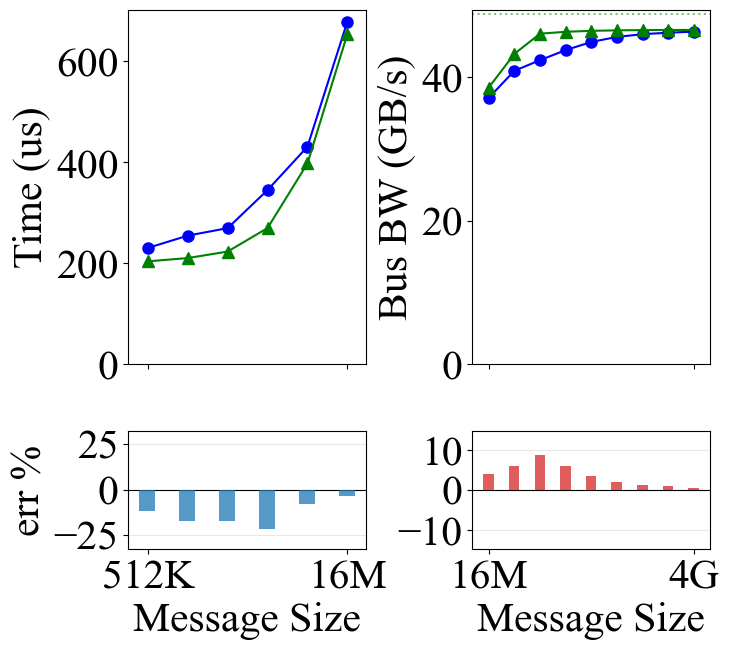

  Ring Simple 4ch (4N): peak meas=46.28, roof=46.52, ratio=0.995


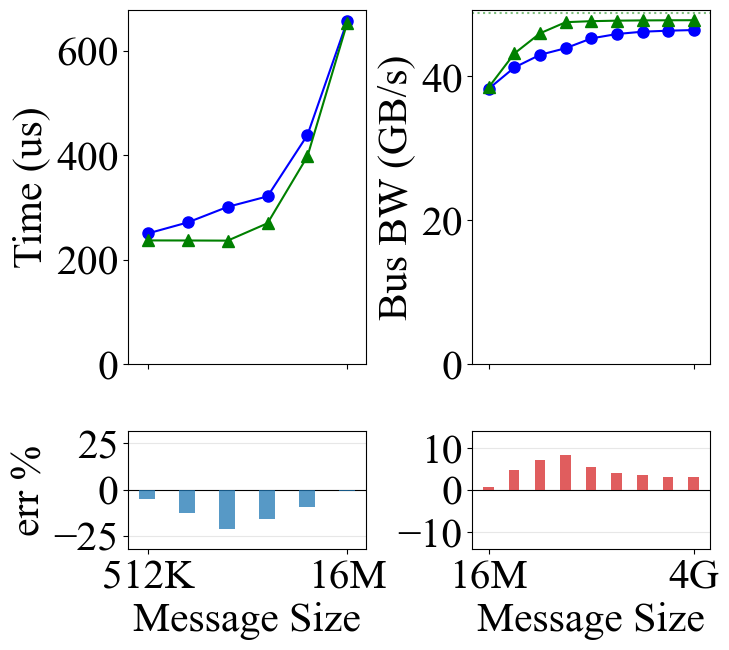

  Ring Simple 8ch (4N): peak meas=46.45, roof=47.81, ratio=0.971


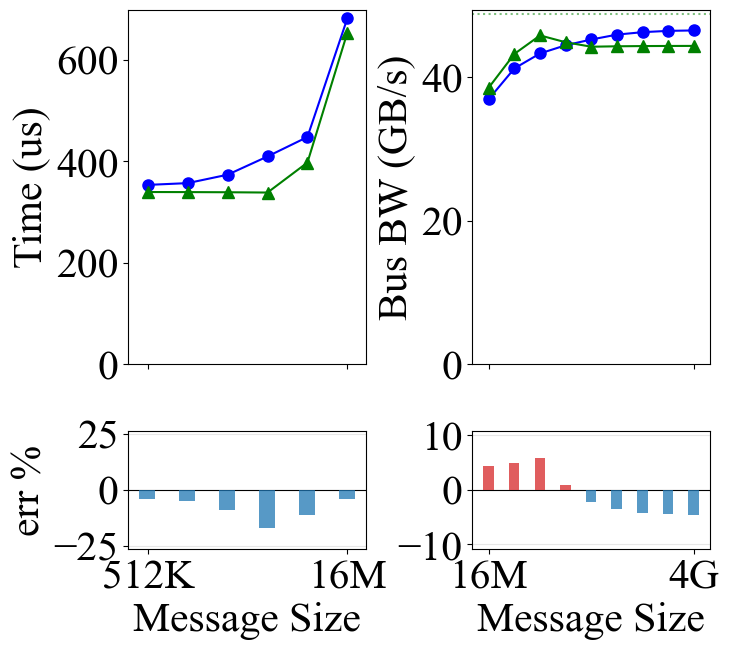

  Ring Simple 16ch (4N): peak meas=46.46, roof=45.76, ratio=1.015


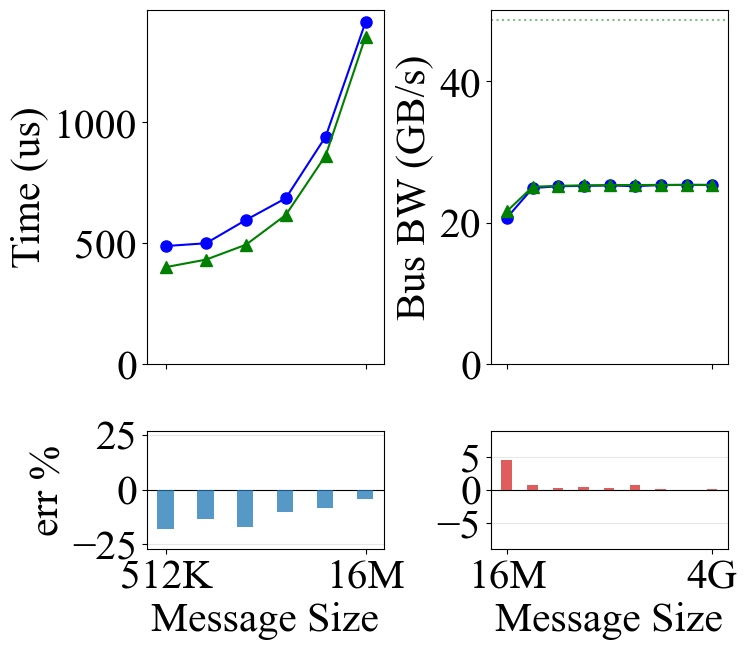

  Ring Simple 1ch (8N): peak meas=25.38, roof=25.38, ratio=1.000


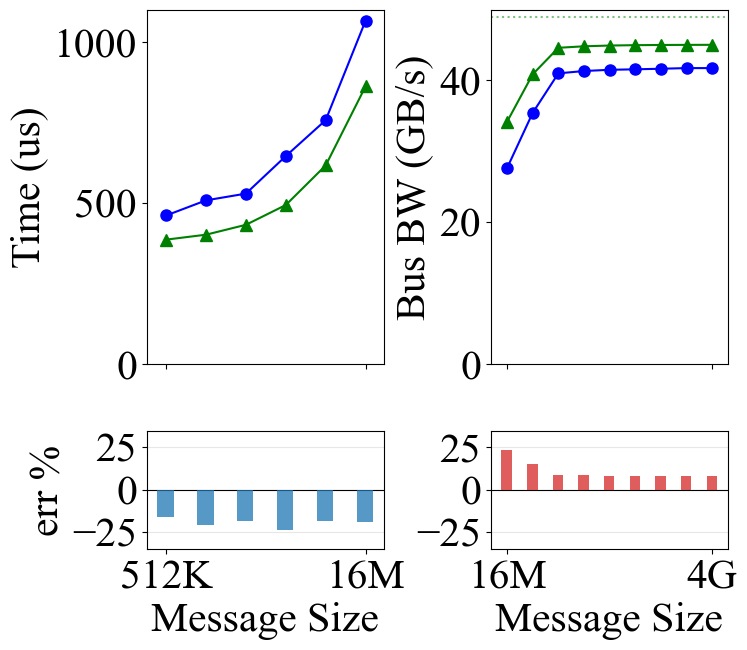

  Ring Simple 2ch (8N): peak meas=41.61, roof=44.88, ratio=0.927


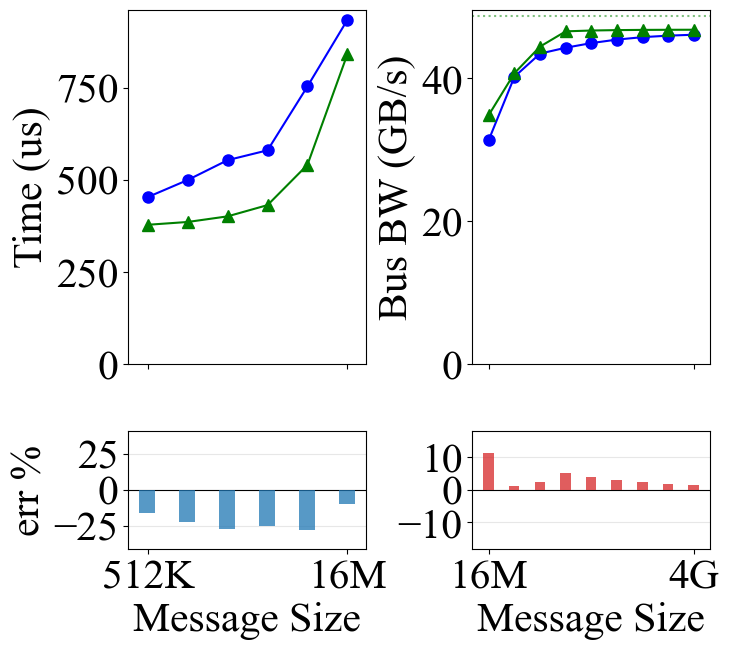

  Ring Simple 4ch (8N): peak meas=46.12, roof=46.82, ratio=0.985


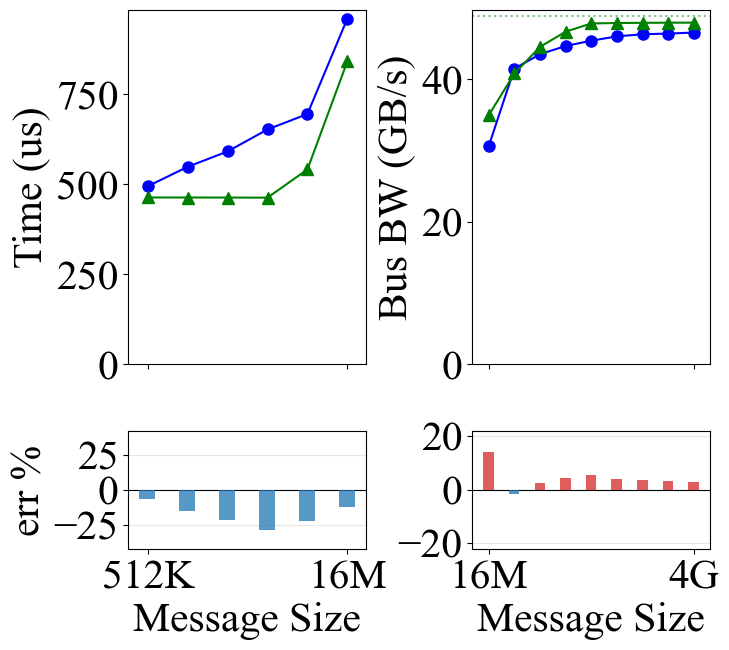

  Ring Simple 8ch (8N): peak meas=46.46, roof=47.85, ratio=0.971


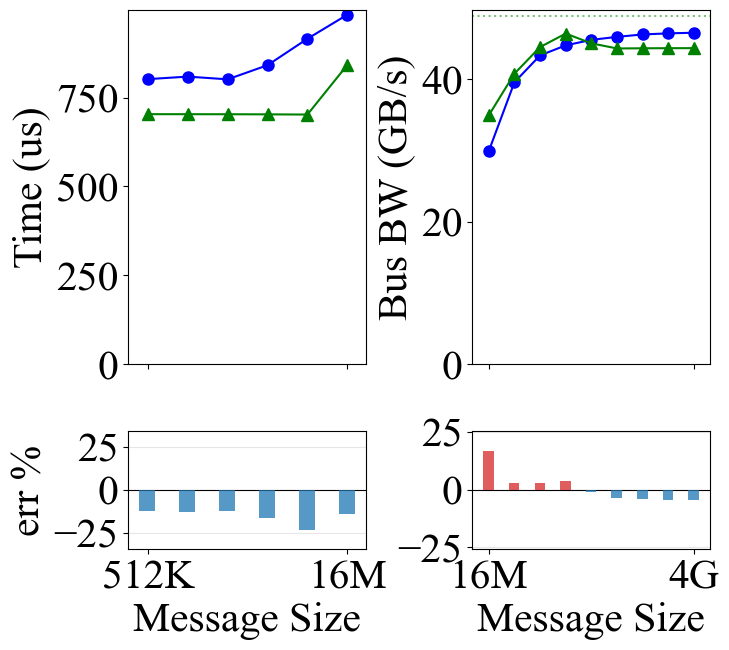

  Ring Simple 16ch (8N): peak meas=46.47, roof=46.35, ratio=1.003


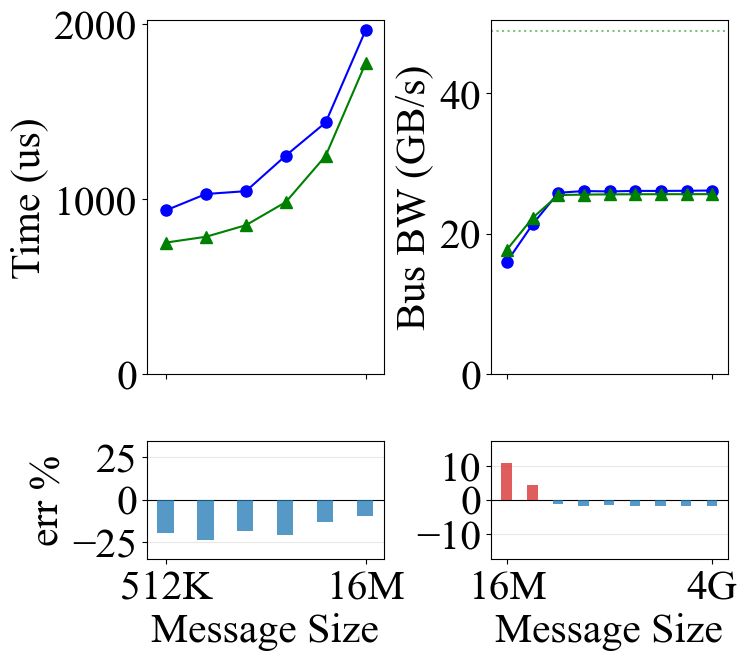

  Ring Simple 1ch (16N): peak meas=26.12, roof=25.60, ratio=1.020


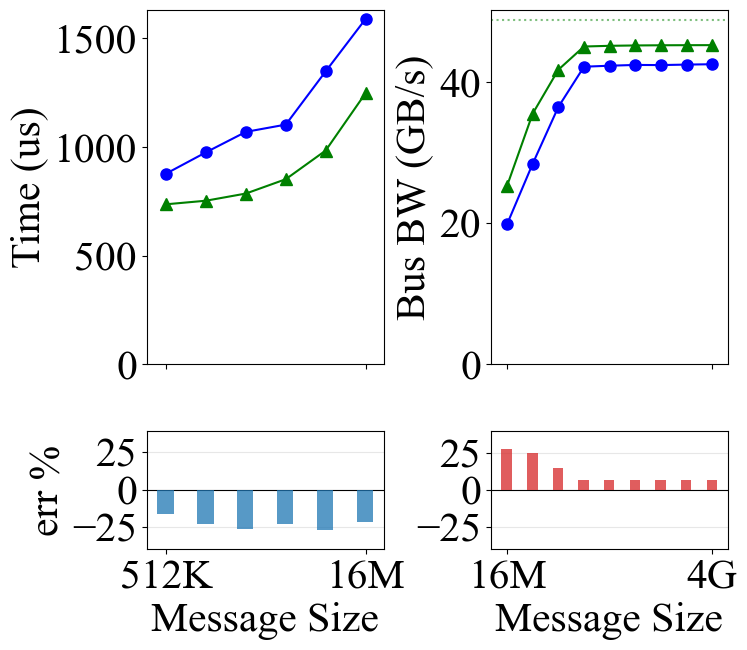

  Ring Simple 2ch (16N): peak meas=42.48, roof=45.18, ratio=0.940


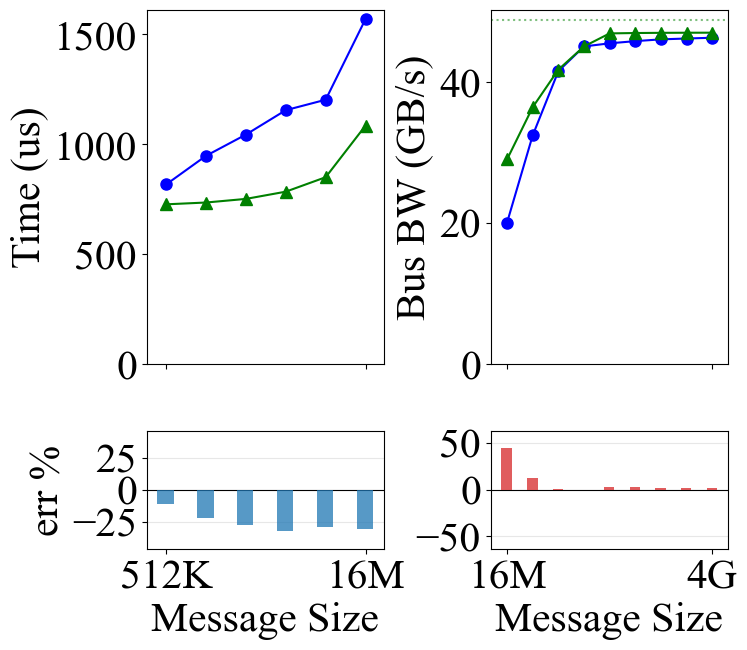

  Ring Simple 4ch (16N): peak meas=46.22, roof=46.94, ratio=0.985


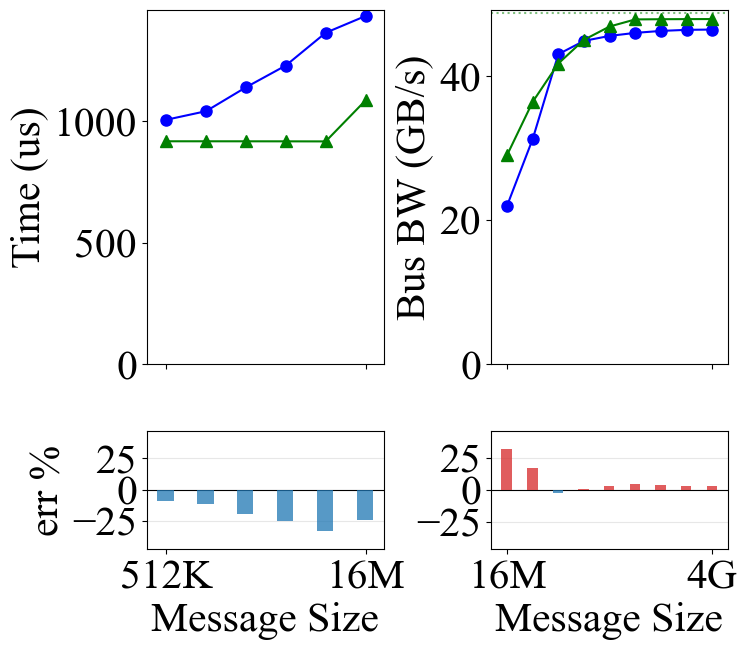

  Ring Simple 8ch (16N): peak meas=46.41, roof=47.86, ratio=0.970


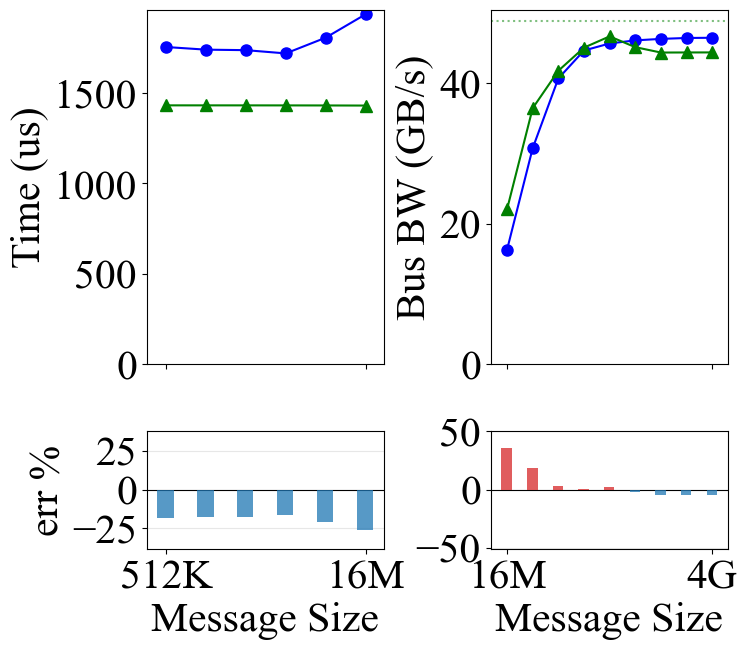

  Ring Simple 16ch (16N): peak meas=46.39, roof=46.59, ratio=0.996


In [ ]:
# Plots: Measured AllReduce (Ring, Simple) vs Realistic Model — one figure per channel
# Each figure = 2 columns (LEFT: latency small sizes, RIGHT: busBW large sizes).
# Each column = main plot + RESIDUAL subplot (shared x): per-point error%
#   error% = (realistic - measured) / measured * 100   (red bar = over-predict, blue = under)

import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

# uniform typography so tiles stay legible when placed side-by-side in one row
SUBFIG_FS = 30    # >>> SINGLE font knob for ALL in-tile text (axes, ticks, err %). cell 34 auto-follows this.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

SIZE_SPLIT = 16 * 1024 * 1024


def format_size_label(x, pos):
    if x >= 1024**3:   return f'{x/1024**3:.0f}G'
    elif x >= 1024**2: return f'{x/1024**2:.0f}M'
    elif x >= 1024:    return f'{x/1024:.0f}K'
    else:              return f'{x:.0f}'

def _err_bars(ax_r, xvals, meas, pred, show_ylabel=True):
    """Bottom residual subplot: per-point error% bars (red=over, blue=under), value labels."""
    xvals = np.asarray(xvals, float); meas = np.asarray(meas, float); pred = np.asarray(pred, float)
    err = np.where(meas > 0, (pred - meas) / meas * 100.0, 0.0)
    colors = ['#d62728' if e >= 0 else '#1f77b4' for e in err]   # red over, blue under
    # bar width in log2 space: constant fraction of each x
    widths = xvals * 0.28
    ax_r.bar(xvals, err, width=widths, color=colors, alpha=0.75, zorder=3)
    ax_r.axhline(0, color='k', lw=0.8)
    ax_r.set_xscale('log', base=2)
    # only label the first and last message size (endpoints); blank the middle ticks
    if len(xvals):
        ax_r.set_xticks([xvals.min(), xvals.max()])
    ax_r.xaxis.set_major_formatter(mticker.FuncFormatter(format_size_label))
    ax_r.xaxis.set_minor_locator(mticker.NullLocator())
    if show_ylabel:
        ax_r.set_ylabel('err %', fontsize=SUBFIG_FS)
    ax_r.tick_params(labelsize=SUBFIG_FS)   # match the main plot's tick size
    ax_r.grid(axis='y', alpha=0.3)
    _m = np.max(np.abs(err)) if len(err) else 10
    ax_r.set_ylim(-1.35*_m - 3, 1.35*_m + 3)

def _plot_pair(dft_small, dft_large, nch, n_nodes_scale, title_prefix):
    fig = plt.figure(figsize=(15/2, 7))   # width halved: each sub-figure's PLOT AREA is truly narrower; height unchanged
    gs = GridSpec(2, 2, height_ratios=[3, 1], hspace=0.28, wspace=0.45, figure=fig)   # hspace: gap between the main plot (top) and err% residual (bottom) so the main y=0 tick doesn't collide with the residual's top tick; wspace: L/R gap so the right column's ylabel doesn't overlap the left plot

    # ---- LEFT: Latency (small sizes) ----
    axL = fig.add_subplot(gs[0, 0]); axLr = fig.add_subplot(gs[1, 0], sharex=axL)
    if len(dft_small) > 0:
        axL.plot(dft_small['size_bytes'], dft_small['time_us'], 'bo-', label=f'Measured ({nch}ch)', markersize=8)
        axL.plot(dft_small['size_bytes'], dft_small['T_realistic_us'], 'g^-', label=f'Realistic ({nch}ch)', markersize=8)
        _err_bars(axLr, dft_small['size_bytes'].values, dft_small['time_us'].values, dft_small['T_realistic_us'].values)
    axL.set_ylabel('Time (us)', fontsize=SUBFIG_FS); axL.set_ylim(0, None)
    axL.tick_params(labelsize=SUBFIG_FS, labelbottom=False)
    axLr.set_xlabel('Message Size', fontsize=SUBFIG_FS)

    # ---- RIGHT: Bus BW (large sizes) ----
    axR = fig.add_subplot(gs[0, 1]); axRr = fig.add_subplot(gs[1, 1], sharex=axR)
    if len(dft_large) > 0:
        axR.plot(dft_large['size_bytes'], dft_large['busbw_GBs'], 'bo-', label=f'Measured ({nch}ch)', markersize=8)
        axR.plot(dft_large['size_bytes'], dft_large['busbw_realistic_GBs'], 'g^-', label=f'Realistic ({nch}ch)', markersize=8)
        _err_bars(axRr, dft_large['size_bytes'].values, dft_large['busbw_GBs'].values, dft_large['busbw_realistic_GBs'].values, show_ylabel=False)   # drop the 'err %' ylabel on the Bus BW column (left column's label already covers it)
    _bf = 2*(n_nodes_scale-1)/n_nodes_scale                      # busBW factor for THIS scale
    _peak = n_nodes_scale/(2*(n_nodes_scale-1)) * G_bytes_per_us/1e3 * _bf   # peak busBW (GB/s)
    axR.axhline(y=_peak, color='green', linestyle=':', alpha=0.5,
                label=f'Peak busBW = {_peak:.1f} GB/s')
    axR.set_ylabel('Bus BW (GB/s)', fontsize=SUBFIG_FS); axR.set_ylim(0, None)
    axR.tick_params(labelsize=SUBFIG_FS, labelbottom=False)
    axRr.set_xlabel('Message Size', fontsize=SUBFIG_FS)

    plt.show()

# One unified loop over all node scales (4/8/16); each figure = one (scale, nch) pair.
for _n_nodes_scale in sorted(all_data.keys()):
    _data = all_data[_n_nodes_scale].get(('Ring', 'Simple'), {})
    for nch in sorted(_data.keys()):
        dft = _data[nch]
        if 'T_realistic_us' not in dft.columns:
            continue
        _lo, _hi = PROTO_SIZE_RANGES['Simple']
        dft_plot = dft[(dft['size_bytes'] >= _lo) & (dft['size_bytes'] <= _hi)]
        if len(dft_plot) == 0:
            continue
        dft_small = dft_plot[dft_plot['size_bytes'] <= SIZE_SPLIT]
        dft_large = dft_plot[dft_plot['size_bytes'] >= SIZE_SPLIT]
        _plot_pair(dft_small, dft_large, nch, _n_nodes_scale, f'Ring Simple ({_n_nodes_scale}N)')

        peak_meas = dft['busbw_GBs'].max(); peak_roof = dft['busbw_realistic_GBs'].max()
        ratio = peak_meas / peak_roof if peak_roof > 0 else 0
        print(f"  Ring Simple {nch}ch ({_n_nodes_scale}N): peak meas={peak_meas:.2f}, roof={peak_roof:.2f}, ratio={ratio:.3f}")


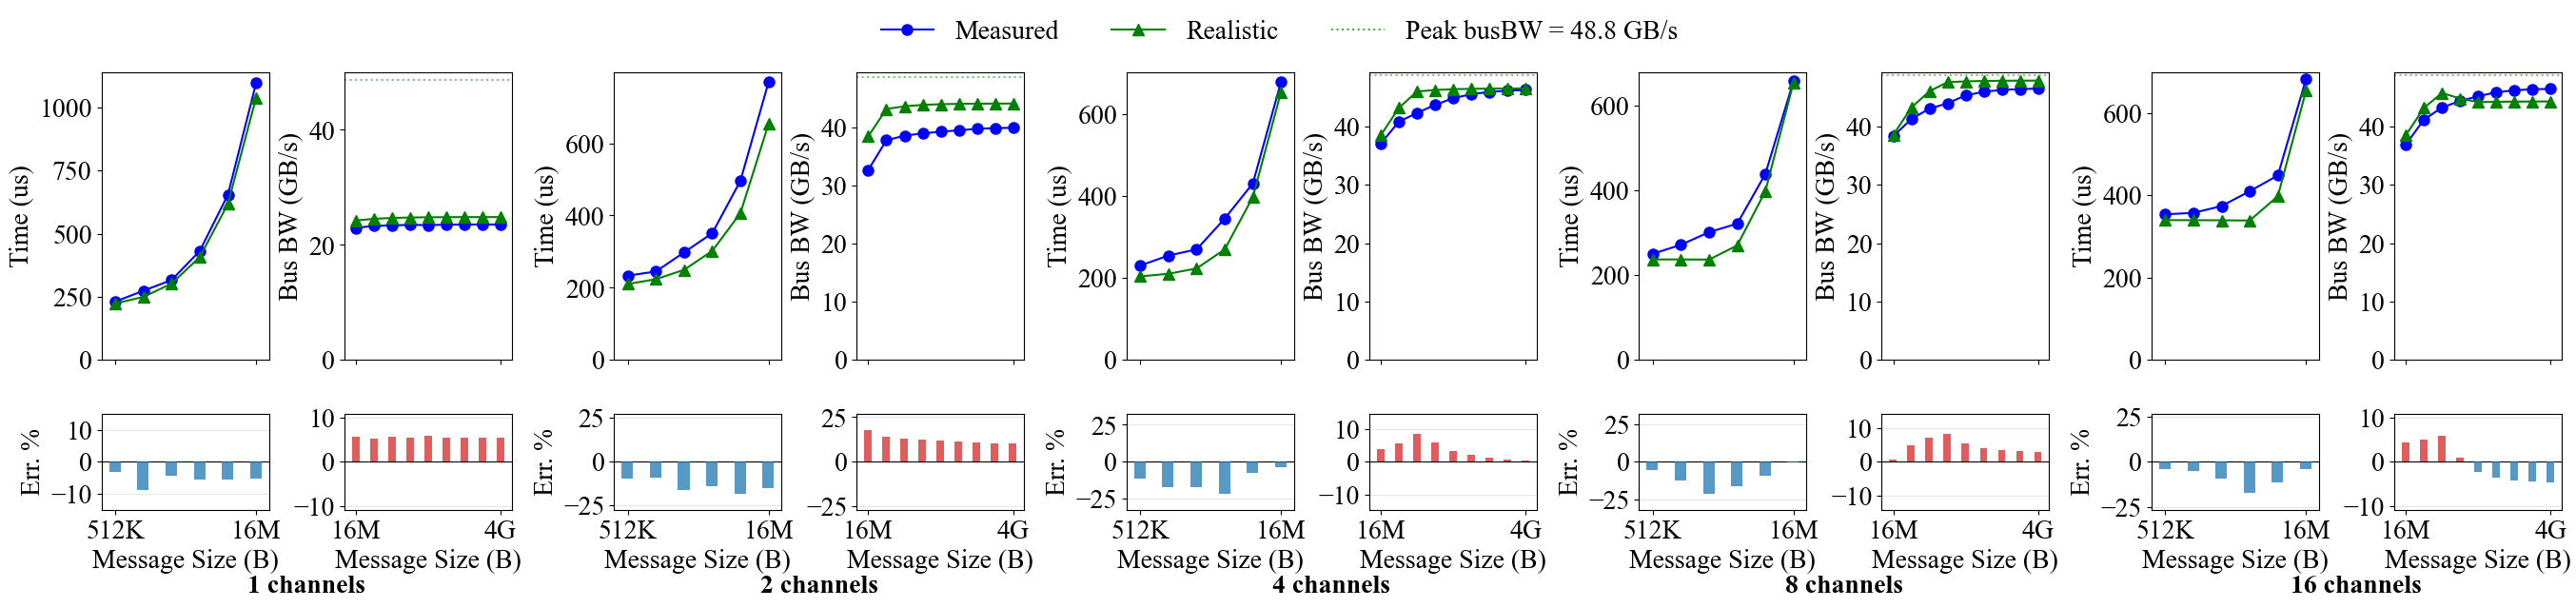

Saved: composite_ring_simple_4N.png  (5 tiles, 27.5x5.5 in @ 450 dpi, from data)


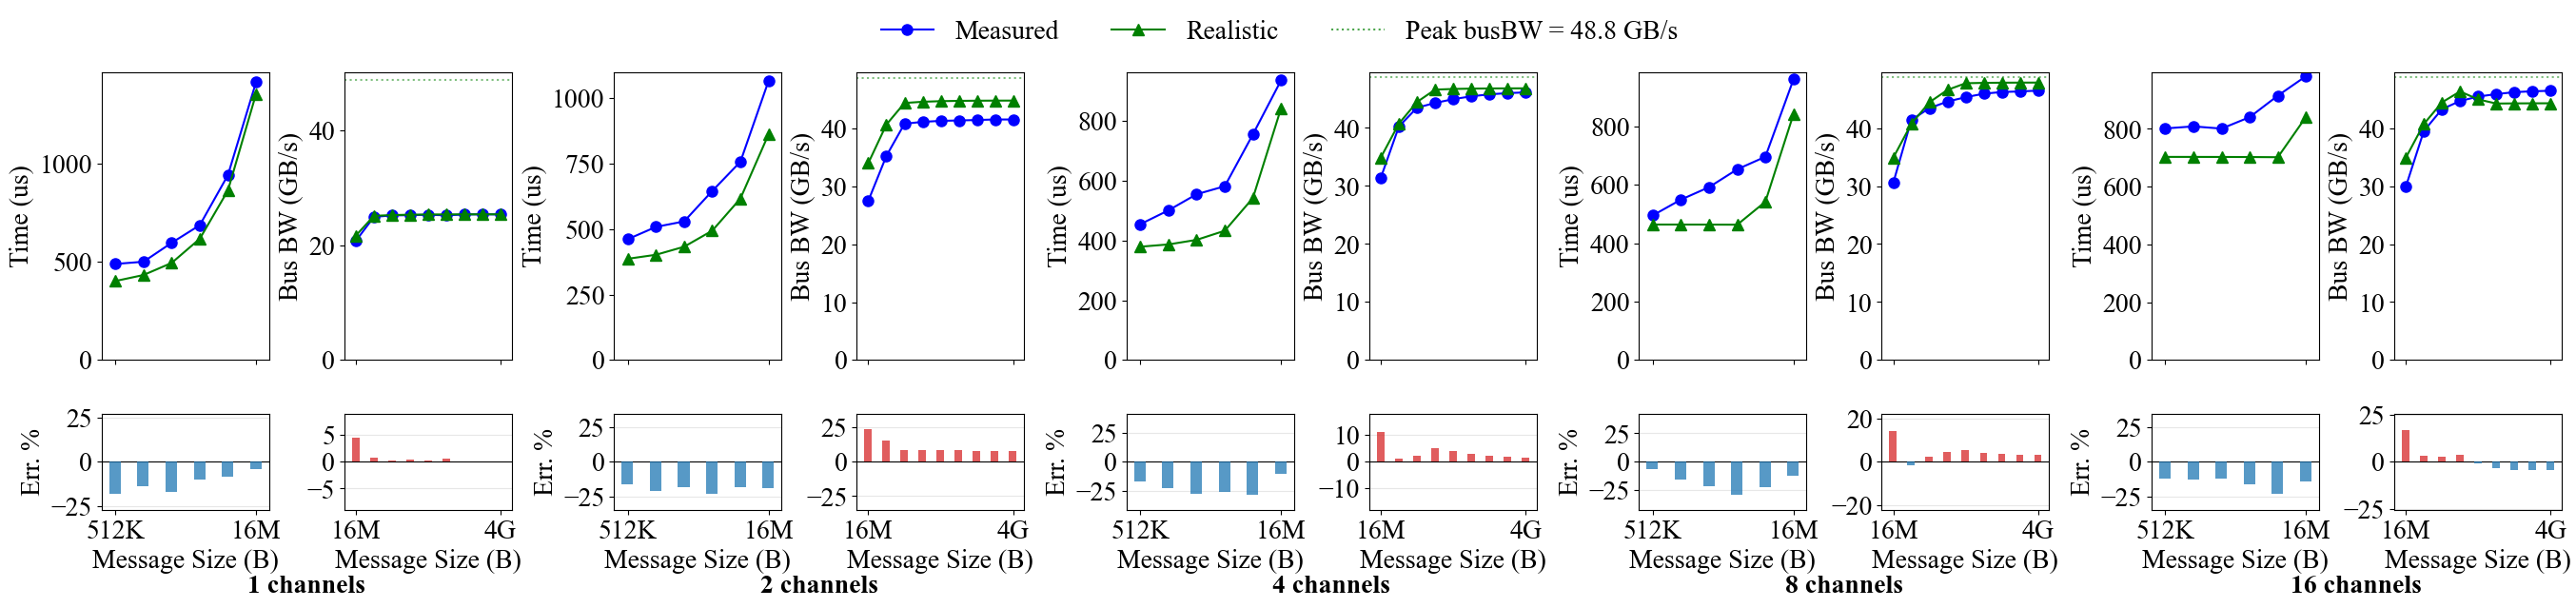

Saved: composite_ring_simple_8N.png  (5 tiles, 27.5x5.5 in @ 450 dpi, from data)


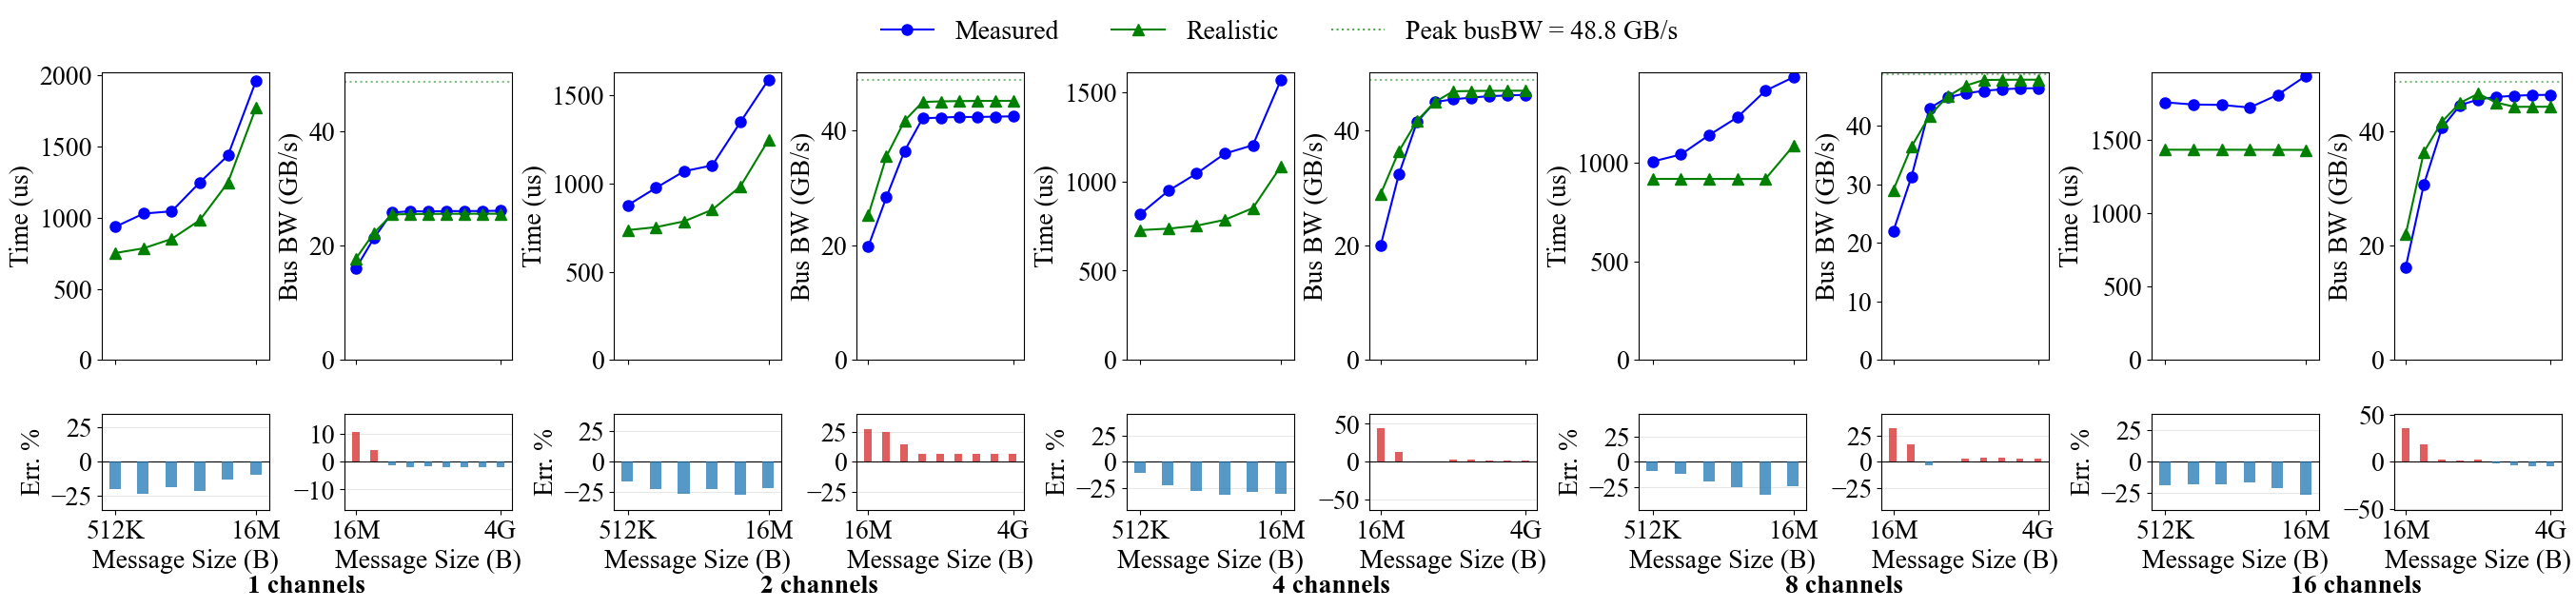

Saved: composite_ring_simple_16N.png  (5 tiles, 27.5x5.5 in @ 450 dpi, from data)


In [7]:
# ==== COMPOSITE (single row): one PNG per scale (4N, 8N, 16N) ====
# Rebuilt to draw DIRECTLY FROM DATA (all_data), not by tiling pre-rendered PNGs.
# Layout is preserved: one wide PNG per node scale, a SINGLE ROW of channel tiles,
# each tile = 2 columns (LEFT Latency small sizes, RIGHT BusBW large sizes), each
# column = main plot (top) + err% residual (bottom). One shared legend on top,
# an "N channels" label under each tile.
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D

# ============================ CONTROL PANEL (edit here) ============================
_GROUP_KEY   = ('Ring', 'Simple')      # which (algo, proto) to composite
_GROUP_TITLE = 'Ring / Simple'
_NODES  = [4, 8, 16]
_NCHS   = [1, 2, 4, 8, 16]

TILE_W    = 5.5                # width  of each channel tile (inches)
TILE_H    = 4.6                # height of each channel tile (inches)
WSPACE_TILES = 0.25            # gap BETWEEN channel tiles (fraction of tile width)
FONT_SIZE = 20                 # in-tile text size (independent knob; SUBFIG_FS=30 is too large when drawn straight into small tiles)
LABEL_H   = 0.45               # bottom strip reserved for the "N channels" labels (inches)
LEGEND_H  = 0.45               # top strip reserved for the shared legend (inches)
LEGEND_GAP = 0.15 / 4          # vertical gap between the legend and the plots below it (inches)
DPI       = 150 * 3            # output resolution
# ===================================================================================

SIZE_SPLIT_C = 16 * 1024 * 1024
_PEAK_N = 4
_PEAK_BUSBW = 1 / (2*(_PEAK_N-1)/(_PEAK_N*G_bytes_per_us)) / 1e3 * (2*(_PEAK_N-1)/_PEAK_N)

def _err_bars_ax(ax_r, xvals, meas, pred, show_ylabel):
    xvals = np.asarray(xvals, float); meas = np.asarray(meas, float); pred = np.asarray(pred, float)
    err = np.where(meas > 0, (pred - meas) / meas * 100.0, 0.0)
    colors = ['#d62728' if e >= 0 else '#1f77b4' for e in err]
    ax_r.bar(xvals, err, width=xvals * 0.28, color=colors, alpha=0.75, zorder=3)
    ax_r.axhline(0, color='k', lw=0.8)
    ax_r.set_xscale('log', base=2)
    if len(xvals):
        ax_r.set_xticks([xvals.min(), xvals.max()])
    ax_r.xaxis.set_major_formatter(mticker.FuncFormatter(format_size_label))
    ax_r.xaxis.set_minor_locator(mticker.NullLocator())
    if show_ylabel:
        ax_r.set_ylabel('Err. %', fontsize=FONT_SIZE)
    ax_r.tick_params(labelsize=FONT_SIZE)
    ax_r.grid(axis='y', alpha=0.3)
    _m = np.max(np.abs(err)) if len(err) else 10
    ax_r.set_ylim(-1.35*_m - 3, 1.35*_m + 3)

for nn in _NODES:
    _data = all_data.get(nn, {}).get(_GROUP_KEY, {})
    chs = [c for c in _NCHS if c in _data and 'T_realistic_us' in _data[c].columns]
    if not chs:
        continue
    n = len(chs)
    fig_w = TILE_W * n
    fig_h = TILE_H + LABEL_H + LEGEND_H
    fig = plt.figure(figsize=(fig_w, fig_h))
    # outer row of tiles; reserve LEGEND_H on top and LABEL_H on bottom
    outer = GridSpec(1, n, figure=fig, wspace=WSPACE_TILES,
                     top=1 - LEGEND_H / fig_h, bottom=LABEL_H / fig_h,
                     left=0.05, right=0.99)
    for k, nch in enumerate(chs):
        dft = _data[nch]
        _lo, _hi = PROTO_SIZE_RANGES['Simple']
        dft = dft[(dft['size_bytes'] >= _lo) & (dft['size_bytes'] <= _hi)]
        dft_small = dft[dft['size_bytes'] <= SIZE_SPLIT_C]
        dft_large = dft[dft['size_bytes'] >= SIZE_SPLIT_C]
        # each tile: 2 cols x 2 rows (main + residual), same proportions as cell 8
        inner = GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, k],
                                        height_ratios=[3, 1], hspace=0.28, wspace=0.45)
        # LEFT: Latency (small)
        axL = fig.add_subplot(inner[0, 0]); axLr = fig.add_subplot(inner[1, 0], sharex=axL)
        if len(dft_small) > 0:
            axL.plot(dft_small['size_bytes'], dft_small['time_us'], 'bo-', markersize=8)
            axL.plot(dft_small['size_bytes'], dft_small['T_realistic_us'], 'g^-', markersize=8)
            _err_bars_ax(axLr, dft_small['size_bytes'].values, dft_small['time_us'].values, dft_small['T_realistic_us'].values, True)
        axL.set_ylabel('Time (us)', fontsize=FONT_SIZE); axL.set_ylim(0, None)
        axL.tick_params(labelsize=FONT_SIZE, labelbottom=False)
        axLr.set_xlabel('Message Size (B)', fontsize=FONT_SIZE)
        # RIGHT: Bus BW (large)
        axR = fig.add_subplot(inner[0, 1]); axRr = fig.add_subplot(inner[1, 1], sharex=axR)
        if len(dft_large) > 0:
            axR.plot(dft_large['size_bytes'], dft_large['busbw_GBs'], 'bo-', markersize=8)
            axR.plot(dft_large['size_bytes'], dft_large['busbw_realistic_GBs'], 'g^-', markersize=8)
            _err_bars_ax(axRr, dft_large['size_bytes'].values, dft_large['busbw_GBs'].values, dft_large['busbw_realistic_GBs'].values, False)
        axR.axhline(y=_PEAK_BUSBW, color='green', linestyle=':', alpha=0.5)
        axR.set_ylabel('Bus BW (GB/s)', fontsize=FONT_SIZE); axR.set_ylim(0, None)
        axR.tick_params(labelsize=FONT_SIZE, labelbottom=False)
        axRr.set_xlabel('Message Size (B)', fontsize=FONT_SIZE)
        # "N channels" label under the tile
        _bb = outer[0, k].get_position(fig)
        fig.text((_bb.x0 + _bb.x1) / 2, LABEL_H / fig_h * 0.15 - 0.1, f'{nch} channels',
                 ha='center', va='bottom', fontsize=FONT_SIZE, fontweight='bold')
    # one shared legend on top
    _ms = 8.0
    _legend_handles = [
        Line2D([0], [0], color='b', marker='o', linestyle='-', markersize=_ms, label='Measured'),
        Line2D([0], [0], color='g', marker='^', linestyle='-', markersize=_ms, label='Realistic'),
        Line2D([0], [0], color='green', linestyle=':', alpha=0.7, label=f'Peak busBW = {_PEAK_BUSBW:.1f} GB/s'),
    ]
    fig.legend(handles=_legend_handles, loc='lower center', ncol=len(_legend_handles),
               fontsize=FONT_SIZE, frameon=False,
               bbox_to_anchor=(0.5, 1 - LEGEND_H / fig_h + LEGEND_GAP / fig_h))
    _out = f'composite_ring_simple_{nn}N.png'
    plt.savefig(_out, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {_out}  ({n} tiles, {fig_w:.1f}x{fig_h:.1f} in @ {DPI} dpi, from data)')
